### Credit Card Fraud Detection

Dataset from Kaggle : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [32]:
path = 'data/creditcard.csv'
df = pd.read_csv(path) #importing csv file
colors = ["#ff0000", "#0000ff"] #color palette for graphs


### EDA

In [33]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [34]:
df.shape

(284807, 31)

The dataset consist of 31 columns and 284807 records.

In [35]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [36]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [37]:
no_fraud = df['Class'].value_counts()[0]
fraud = df["Class"].value_counts()[1]
print("No Fraud:", no_fraud)
print("Fraud:", fraud)

percentage_of_no_fraud = round(no_fraud/len(df) * 100, 2)
percentage_of_fraud = round(fraud/len(df) * 100, 2)
print(percentage_of_no_fraud, "% of No Fraund in dataset.")
print(percentage_of_fraud, "% of Fraud in dataset.")

No Fraud: 284315
Fraud: 492
99.83 % of No Fraund in dataset.
0.17 % of Fraud in dataset.


The dataset is imbalace. The model will overfit and assume that most transaction are NOT FRAUD.

Text(0.5, 1.0, 'Class Distribution \n (0: No Fraud || 1: Fraud)')

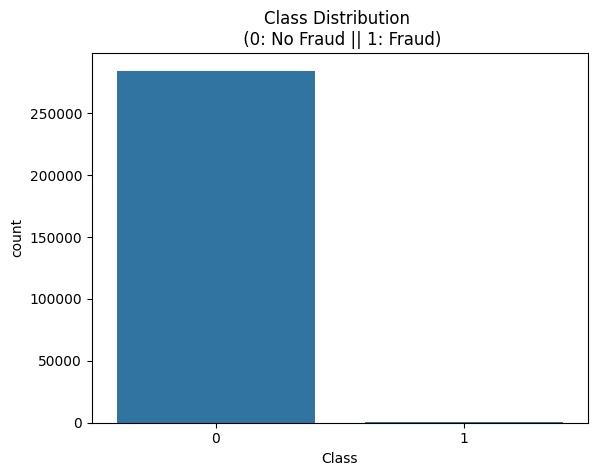

In [38]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution \n (0: No Fraud || 1: Fraud)")


We can see how skew the data is.

### Feature Engineering

Robust Scaler to scale remaning columns "Amount" & "Time"

In [39]:
#Scaling Remaining Columns : Time and Amount
from sklearn.preprocessing import RobustScaler

rob_scalar = RobustScaler() # Robust Scalar is less prone to outliers


scaled_df = df.copy(deep=True)
scaled_df['scaled_amount'] = rob_scalar.fit_transform(scaled_df['Amount'].values.reshape(-1,1))
scaled_df['scaled_time'] = rob_scalar.fit_transform(scaled_df['Time'].values.reshape(-1,1))



In [40]:
scaled_df.drop(['Amount', 'Time'], axis=1, inplace=True) 

In [41]:
scaled_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,-0.994960


#### Undersampling : Creating a dataframe with 50/50 ratio of fraud and non-fraud transaction.

Undersampling a dataset to have 50/50 Fraud/No Fraud Data

In [42]:
#Shuffing the data
scaled_df = scaled_df.sample(frac=1)

# amount of fraud classes 492 rows
fraud_df = scaled_df[df['Class'] == 1]
non_fraud_df = scaled_df[df['Class'] == 0][:492] #492 records only

normal_distributed_pdf = pd.concat([fraud_df, non_fraud_df])

#shuffle dataframe rows again
new_df = normal_distributed_pdf.sample(frac=1, random_state=42)
new_df.head()

/tmp/ipykernel_36331/725605322.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  fraud_df = scaled_df[df['Class'] == 1]
/tmp/ipykernel_36331/725605322.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  non_fraud_df = scaled_df[df['Class'] == 0][:492] #492 records only


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
226894,0.378179,-0.467254,1.000234,0.046029,-1.852843,0.247299,-0.244300,-0.087864,-0.802849,0.828008,...,0.996356,-0.146759,-0.030921,0.520821,0.521648,-0.210010,-0.327484,0,2.214770,0.706752
263877,-3.387601,3.977881,-6.978585,1.657766,-1.100500,-3.599487,-3.686651,1.942252,-3.065089,-7.509557,...,0.262189,-0.479224,-0.326638,-0.156939,0.113807,0.354124,0.287592,1,-0.302103,0.898295
80771,1.377808,-0.821876,1.137418,-0.727704,-1.575369,-0.255962,-1.354039,0.090020,-0.080914,0.593035,...,1.095638,-0.142871,-0.081482,0.366134,-0.010597,0.053868,0.028072,0,-0.084539,-0.306007
91671,-0.639191,-0.085595,1.265452,1.401166,-0.260542,1.009795,1.301999,-0.135258,-0.431521,-0.091353,...,0.760170,0.353377,-0.778893,-0.070681,-0.033355,-0.061962,-0.062687,1,3.747363,-0.248053
274382,-5.766879,-8.402154,0.056543,6.950983,9.880564,-5.773192,-5.748879,0.721743,-1.076274,2.688670,...,-0.130436,2.241471,0.665346,-1.890041,-0.120803,0.073269,0.583799,1,-0.307413,0.955004


In [43]:
new_df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,-2.378928,1.778505,-3.554488,2.284181,-1.556899,-0.719466,-2.747645,0.312701,-1.303047,-2.814241,...,0.019979,-0.026552,-0.045566,0.037131,0.030768,0.085990,0.041490,0.500000,1.234245,0.045544
std,5.532901,3.728015,6.203803,3.170482,4.229786,1.725718,5.865567,4.847614,2.304457,4.550333,...,1.165886,1.196431,0.580429,0.679477,0.468042,1.000157,0.457536,0.500254,3.775833,0.565182
min,-30.552380,-13.158419,-31.103685,-4.005317,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,-24.588262,...,-8.887017,-19.254328,-2.028024,-4.781606,-1.398926,-7.263482,-2.748073,0.000000,-0.307413,-0.994079
25%,-2.939486,-0.201839,-5.129049,-0.058180,-1.843492,-1.576412,-3.103817,-0.223490,-2.324444,-4.572043,...,-0.518590,-0.251926,-0.392124,-0.300566,-0.287840,-0.070605,-0.057154,0.000000,-0.293440,-0.455409
50%,-0.759404,0.896993,-1.383992,1.285786,-0.428249,-0.682932,-0.599528,0.134685,-0.728456,-0.870736,...,0.033940,-0.040490,0.014404,0.073378,-0.001536,0.046101,0.035099,0.500000,-0.041640,-0.037348
75%,1.082848,2.793742,0.314152,4.250632,0.492140,0.061598,0.293604,0.851557,0.096332,0.046991,...,0.575323,0.191319,0.391707,0.423494,0.329931,0.454884,0.220976,1.000000,1.089779,0.612895
max,2.369552,22.057729,3.203999,12.114672,11.095089,6.474115,5.903436,20.007208,4.920913,8.151260,...,8.361985,5.466230,1.177063,2.208209,2.745261,3.052358,4.773118,1.000000,55.306365,1.034904


/tmp/ipykernel_36331/3399929641.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=new_df, palette=['#a1c9f4', '#8de5a1'])


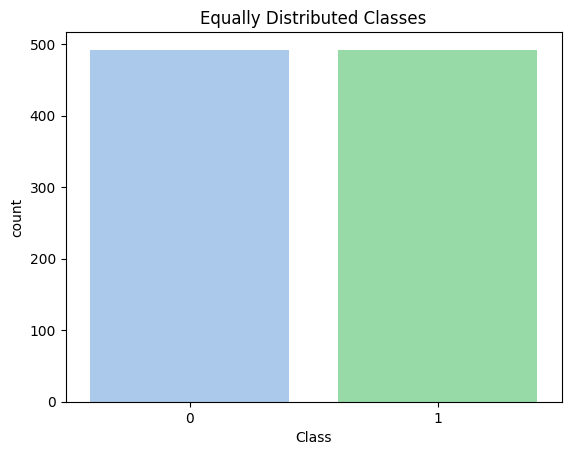

In [44]:
sns.countplot(x='Class', data=new_df, palette=['#a1c9f4', '#8de5a1'])
plt.title("Equally Distributed Classes")
plt.show()

New dataframe with 50% Fraud and 50% Non Fraud

### Second EDA

Correlation Metric to better understand our data. We want to know if there are features that influence heavily in whether a specific is a fraud.

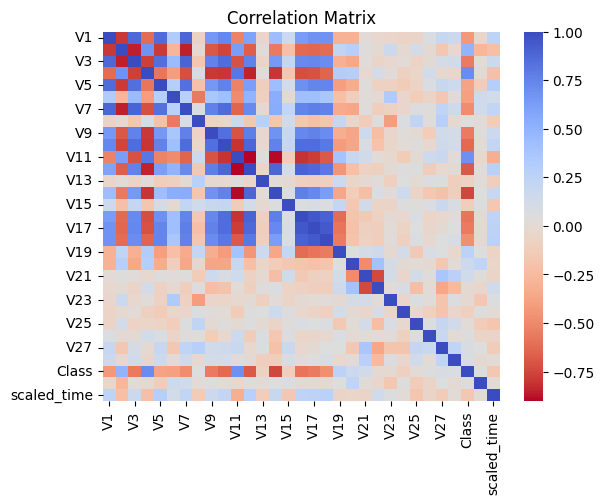

In [45]:
sns.heatmap(new_df.corr(), cmap='coolwarm_r')
plt.title("Correlation Matrix")
plt.show()

<b>Explanation</b>: 

Negative Correlations: V17, V14, V12 and V10 are negatively correlated. Meaning lower these values are, the more likely the end result will be fraud transaction.

Positive Correlations: V2, V4, V11 and V19 are positively correlated. Higher these values, more likely the ned result will be fraud transaction.

### Removing Outliers

#### Negative Correlations

Removing extreme outliers for better model accuracy

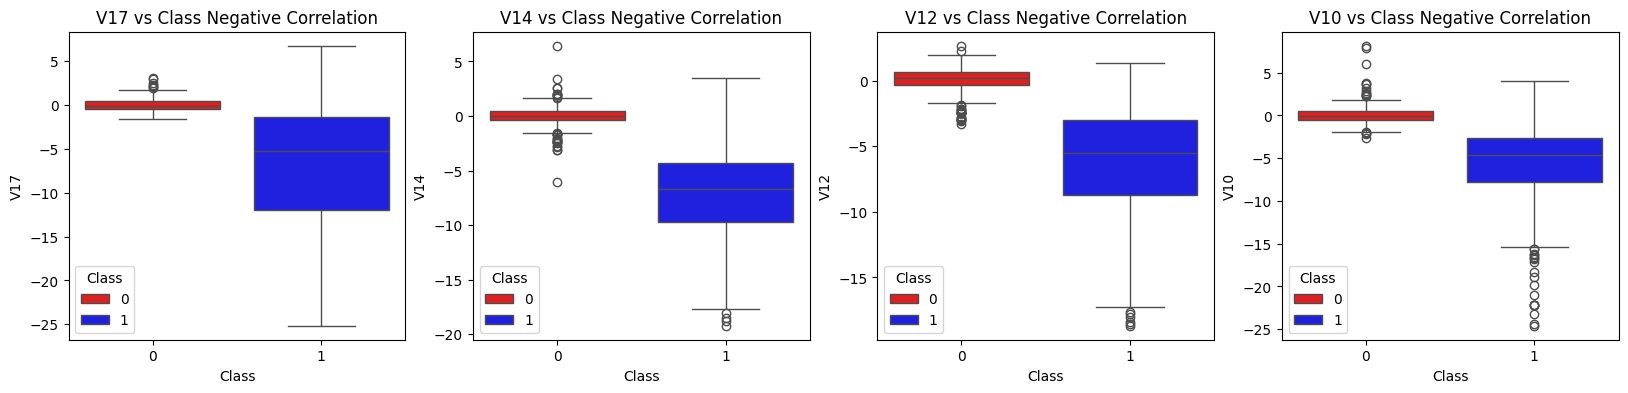

In [46]:
f, axes = plt.subplots(ncols=4, figsize =(20,4))
sns.boxplot(x='Class', y="V17", data=new_df, ax=axes[0], palette=colors, hue="Class")
axes[0].set_title("V17 vs Class Negative Correlation")

sns.boxplot(x='Class', y="V14", data=new_df, ax=axes[1], palette=colors, hue="Class")
axes[1].set_title("V14 vs Class Negative Correlation")

sns.boxplot(x='Class', y="V12", data=new_df, ax=axes[2], palette=colors,  hue="Class")
axes[2].set_title("V12 vs Class Negative Correlation")

sns.boxplot(x='Class', y="V10", data=new_df, ax=axes[3], palette=colors,  hue="Class")
axes[3].set_title("V10 vs Class Negative Correlation")
plt.show()

#### Positive Correlation

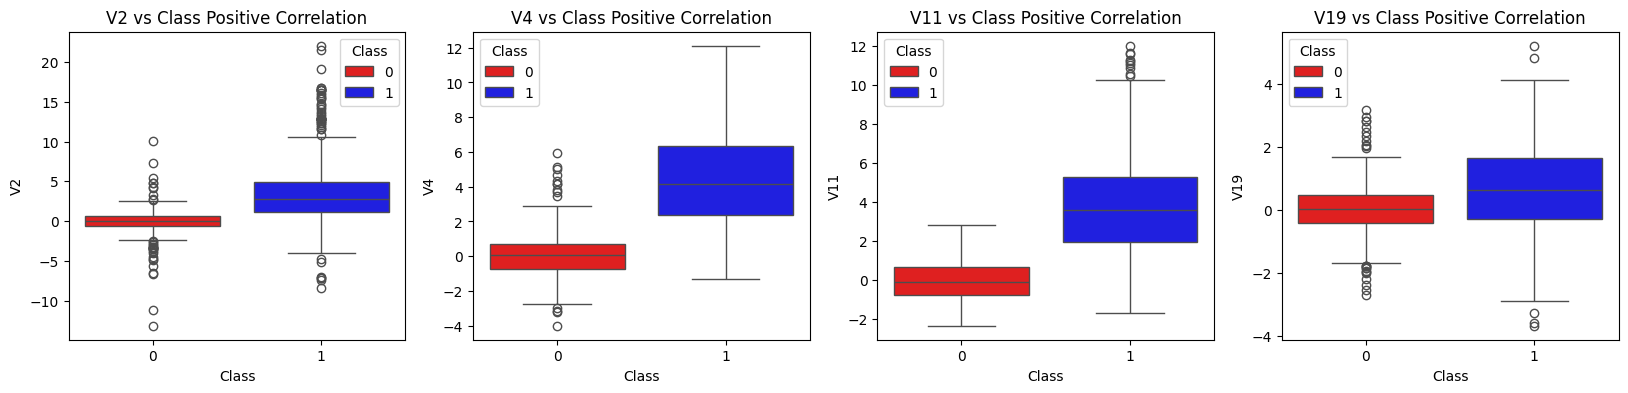

In [47]:
f, axes = plt.subplots(ncols=4, figsize =(20,4))
sns.boxplot(x='Class', y="V2", data=new_df, ax=axes[0], palette=colors, hue="Class")
axes[0].set_title("V2 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V4", data=new_df, ax=axes[1], palette=colors, hue="Class")
axes[1].set_title("V4 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V11", data=new_df, ax=axes[2], palette=colors,  hue="Class")
axes[2].set_title("V11 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V19", data=new_df, ax=axes[3], palette=colors,  hue="Class")
axes[3].set_title("V19 vs Class Positive Correlation")
plt.show()

#### Removing V2 and V10 Feature outlier

Removing too much outliers can lose information make a model underfit.

In [48]:
#IQR
#For V2
v2_fraud = new_df['V2'].loc[new_df['Class']==1].values
q25, q75 = np.percentile(v2_fraud, 25), np.percentile(v2_fraud, 75)
v2_iqr = q75 - q25

v2_cut_off = v2_iqr * 1.5
v2_lower, v2_upper = q25 - v2_cut_off, q75 + v2_cut_off

new_df = new_df.drop(new_df[(new_df['V2'] > v2_upper) | (new_df['V2'] < v2_lower)].index) #removing outlier


In [49]:
#For V10
v10_fraud = new_df['V10'].loc[new_df['Class']==1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off

new_df = new_df.drop(new_df[(new_df['V10'] > v10_upper) | (new_df['V10'] < v10_lower)].index) #removing outlier

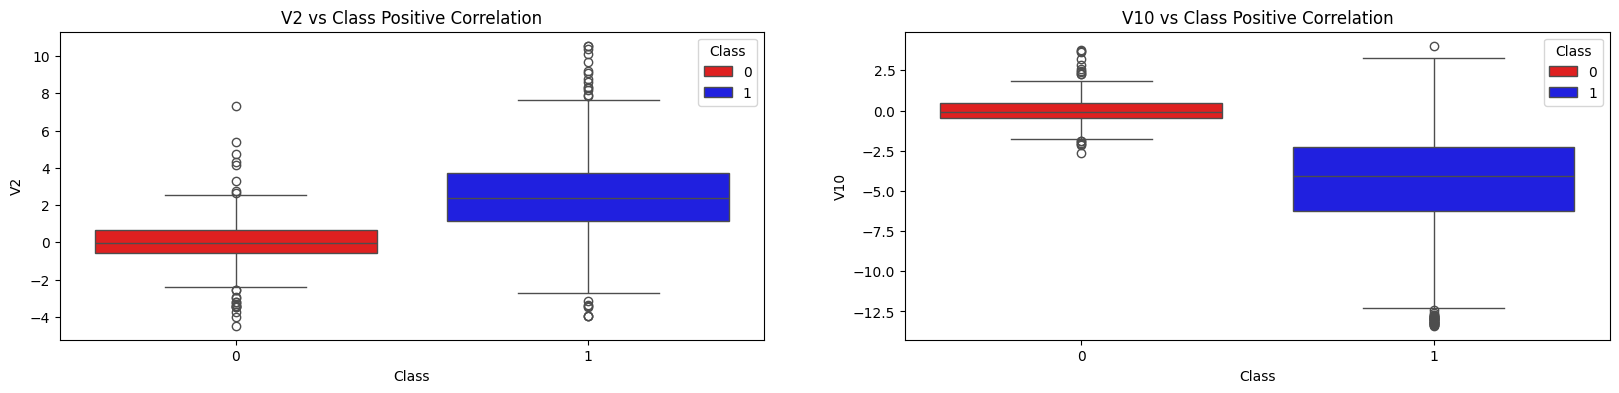

In [50]:
#Boxplot after removing IQR
f, axes = plt.subplots(ncols=2, figsize =(20,4))
sns.boxplot(x='Class', y="V2", data=new_df, ax=axes[0], palette=colors, hue="Class")
axes[0].set_title("V2 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V10", data=new_df, ax=axes[1], palette=colors, hue="Class")
axes[1].set_title("V10 vs Class Positive Correlation")
plt.show()


In [51]:
#Remaining rows
new_df.shape

(905, 31)

### Model Training

Since it is a classification problem we have used Logistic Regression and XGboost models.

Train-Test-Split and Validation Data set

70% Train Data

15% Test Data

15% Validate Data

In [ ]:
from sklearn.model_selection import train_test_split

# Features & target
X = new_df.drop('Class', axis=1)
y = new_df['Class'] #target

# Splitting a data for train and (test + validate)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#Splitting temp data set to test and validate
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Validate set shape:", X_val.shape)

Training set shape: (633, 30)
Test set shape: (136, 30)
Validate set shape: (136, 30)


Fitting models with dataset

In [62]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

#XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

#### Prediction

In [66]:
#Logistics Prediction
y_pred_lr = log_reg.predict(X_test)

#XGBoost Prediction
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Evaluation
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.9191176470588235

Confusion Matrix:
 [[65  2]
 [ 9 60]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92        67
           1       0.97      0.87      0.92        69

    accuracy                           0.92       136
   macro avg       0.92      0.92      0.92       136
weighted avg       0.92      0.92      0.92       136



In [61]:
# Evaluation
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy: 0.9264705882352942

Confusion Matrix:
 [[65  2]
 [ 8 61]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93        67
           1       0.97      0.88      0.92        69

    accuracy                           0.93       136
   macro avg       0.93      0.93      0.93       136
weighted avg       0.93      0.93      0.93       136



ROC Curve Comparison between two models

Logistic Regression ROC AUC: 0.9725062171870682
XGBoost ROC AUC: 0.9708483006355346


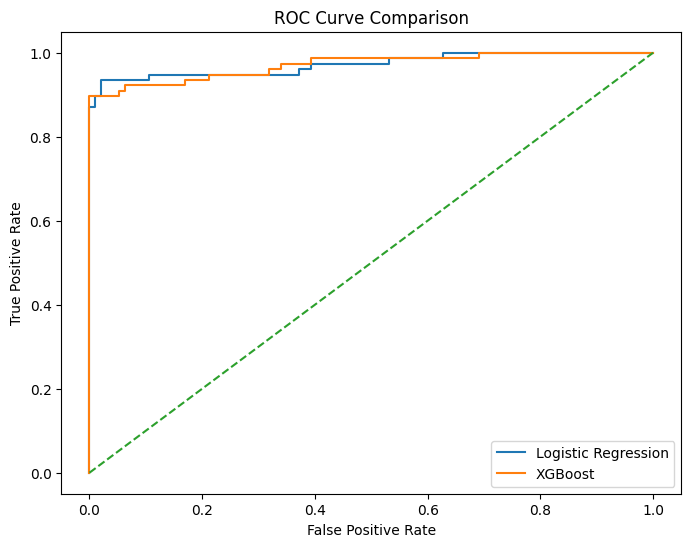

In [31]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probabilities
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ROC AUC scores
print("Logistic Regression ROC AUC:", roc_auc_score(y_test, y_prob_lr))
print("XGBoost ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


Prediction on New / Test Samples

In [32]:
# Example: predicting first 5 samples from test set
sample_data = X_test.iloc[:5]

lr_predictions = log_reg.predict(sample_data)
xgb_predictions = xgb_model.predict(sample_data)

print("Logistic Regression Predictions:", lr_predictions)
print("XGBoost Predictions:", xgb_predictions)

Logistic Regression Predictions: [0 0 0 1 0]
XGBoost Predictions: [0 0 0 1 0]


### Evaluation